In [ ]:
import pandas as pd
import numpy as np

# 1. Load each CSV into its own DataFrame.
df_behavior = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Behaviour_new.csv")  # columns: user_id, anxious, calm, ...
df_class    = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Class_new.csv")     # columns: user_id, course_id, ...
df_mood     = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Mood_new.csv")      # columns: user_id, happy, sad, ...
df_stress   = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Stress_new.csv")    # columns: user_id, level, ...
df_class2  = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Class.csv")
df_event  = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Events.csv")
df_exercise   = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Exercise.csv")
df_sleep  = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Sleep.csv")
df_social   = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/EMA/Social.csv")
df_gpa = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/static/grades.csv")


# 2) Create a new column with the Unix timestamp in seconds
df_exercise['datetime_utc'] = df_exercise['resp_time']
# # 2) Create a new column with the Unix timestamp in seconds
df_class2['resp_time'] = pd.to_datetime(df_class2['resp_time'], utc=True, unit='s', origin='unix')
df_class2['datetime_utc'] = df_class2['resp_time']

In [ ]:
df_behavior.head(10)

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,resp_time,sympathetic,datetime_utc
0,u00,4,4.0,5.0,2,3.0,3.0,4.0,4.0,3.0,1365455068,4.0,2013-04-08 21:04:28+00:00
1,u00,5,3.0,3.0,1,4.0,4.0,4.0,3.0,1.0,1365621587,4.0,2013-04-10 19:19:47+00:00
2,u00,4,3.0,3.0,3,4.0,2.0,4.0,4.0,2.0,1366145919,4.0,2013-04-16 20:58:39+00:00
3,u00,4,5.0,2.0,1,4.0,3.0,5.0,3.0,1.0,1366229877,4.0,2013-04-17 20:17:57+00:00
4,u00,3,3.0,3.0,3,3.0,3.0,3.0,4.0,3.0,1366663342,4.0,2013-04-22 20:42:22+00:00
5,u00,5,3.0,4.0,5,3.0,4.0,2.0,1.0,3.0,1366867587,4.0,2013-04-25 05:26:27+00:00
6,u00,5,3.0,4.0,2,5.0,1.0,4.0,3.0,1.0,1367008911,3.0,2013-04-26 20:41:51+00:00
7,u00,3,NaN,NaN,3,3.0,3.0,3.0,3.0,3.0,1368576414,3.0,2013-05-15 00:06:54+00:00
8,u00,3,2.0,2.0,3,3.0,2.0,3.0,2.0,2.0,1368662695,2.0,2013-05-16 00:04:55+00:00
9,u00,4,4.0,3.0,2,3.0,3.0,2.0,3.0,5.0,1368837399,4.0,2013-05-18 00:36:39+00:00


In [ ]:
# order df1 to df9
dfs_list = [df_behavior, df_class, df_mood, df_stress, df_class2,
            df_event, df_exercise, df_sleep, df_social]


In [ ]:
df_behavior.head()

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,resp_time,sympathetic,datetime_utc
0,u00,4,4.0,5.0,2,3.0,3.0,4.0,4.0,3.0,1365455068,4.0,2013-04-08 21:04:28+00:00
1,u00,5,3.0,3.0,1,4.0,4.0,4.0,3.0,1.0,1365621587,4.0,2013-04-10 19:19:47+00:00
2,u00,4,3.0,3.0,3,4.0,2.0,4.0,4.0,2.0,1366145919,4.0,2013-04-16 20:58:39+00:00
3,u00,4,5.0,2.0,1,4.0,3.0,5.0,3.0,1.0,1366229877,4.0,2013-04-17 20:17:57+00:00
4,u00,3,3.0,3.0,3,3.0,3.0,3.0,4.0,3.0,1366663342,4.0,2013-04-22 20:42:22+00:00


In [ ]:
#new
import pandas as pd
import numpy as np

def weekly_aggregate_all_cols(
    df,
    user_col='user_id',
    time_col='datetime_utc',
    mean_cols=None
):
    """
    Aggregate each column of 'df' by (user_id, 1-week).
      - For columns in 'mean_cols': use mean.
      - For all other columns: use mode (taking the first if multiple).
    Keeps 'user_id' as the final index and 'datetime_utc' as a column.
    """
    if mean_cols is None:
        mean_cols = []

    # # 1) Ensure time_col is a proper datetime
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce', utc=True, unit='ns', origin='unix')

    # 2) Define a helper for mode (to avoid returning multiple values on ties)
    def first_mode(series):
        modes = series.mode(dropna=True)
        return modes.iloc[0] if len(modes) > 0 else np.nan

    # 3) Build the aggregation dict:
    #    - If col is in mean_cols => mean
    #    - Otherwise => mode
    agg_dict = {}
    for col in df.columns:
        if col in [user_col, time_col]:
            continue
        if col in mean_cols:
            agg_dict[col] = 'mean'
        else:
            agg_dict[col] = first_mode

    # 4) Set the time as index, group by user_id, then resample weekly
    df = df.set_index(time_col)
    grouped = df.groupby(user_col, group_keys=False).resample('1W')

    # 5) Aggregate
    df_agg = grouped.agg(agg_dict)
    # 6) Right now 'df_agg' is a multi-index of [user_col, time_col].
    #    We'll reset only the time_col level so that user_col stays as the index.
    # df_agg.reset_index(level=time_col, inplace=True)

    # # 7) Rename the time_col for clarity
    # df_agg.rename(columns={time_col: 'datetime_utc'}, inplace=True)
    df_agg.reset_index(inplace=True)
    df_agg.rename(columns={time_col: 'datetime_utc', user_col: 'user_id'}, inplace=True)

    #    At this point:
    #      - The index is user_col
    #      - We have a column named 'datetime_utc'
    #      - The other columns are the aggregated columns
    return df_agg



In [ ]:


#process data and combine
weekly_dfs = []
mean_columns=[]
for df in dfs_list:
  df["userid"] = df["user_id"]

for i, df in enumerate(dfs_list):
    if 'datetime_utc' not in df.columns:
        # skip or handle differently if no user_id/time
        print(f"Skipping df index {i} - missing 'datetime_utc'")
        continue

    df_weekly = weekly_aggregate_all_cols(
                df,
                user_col='user_id',
                time_col='datetime_utc',
                mean_cols=mean_columns
            )
    weekly_dfs.append(df_weekly)



for df in weekly_dfs:
    df.dropna(inplace=True)

# Now merge all weekly-aggregated DFs on [user_id, datetime_utc] with outer join


dfs_list = [df_behavior, df_class, df_mood, df_stress, df_class2,
            df_event, df_exercise, df_sleep, df_social]
def merge_many_on_user_time(dfs):
    if not dfs:
        return pd.DataFrame()
    merged = dfs[0].copy()
    for i in range(1, len(dfs)):
        merged = pd.merge(
            merged,
            dfs[i],
            on=["user_id", "datetime_utc"],
            how="outer",
            suffixes=("", f"_df{i}")
        )
    return merged

df_combined = merge_many_on_user_time(dfs_list)

df_combined.head()

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,resp_time_df7,sleep_hours,sleep_quality,sleepiness,location_df7,userid_df7,resp_time_df8,number,location_df8,userid_df8
0,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.364114e+09,NaN,NaN,NaN,NaN,u00,NaN,NaN,NaN,NaN
1,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.364114e+09,NaN,NaN,u00
2,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.364114e+09,NaN,NaN,u00
3,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.364114e+09,NaN,NaN,NaN,NaN,u00,NaN,NaN,NaN,NaN
4,u00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.364114e+09,NaN,NaN,u00


In [ ]:
# Merge gpa_all from df_gpa into df_combined based on matching IDs
df_combined = df_combined.merge(
    df_gpa[['uid', 'gpa all']],
    left_on='user_id',
    right_on='uid',
    how='left'
)

# Rename and clean up
df_combined.rename(columns={'gpa all': 'gpa_all'}, inplace=True)
df_combined.drop(columns=['uid'], inplace=True)


In [ ]:
# prompt: print na values if they are more less than 8700

na_counts = df_combined.isna().sum()
print(na_counts[na_counts > 8500])


Series([], dtype: int64)


In [ ]:
feature_cols =  [
'anxious',
'calm',
'conventional',
'critical',
'dependable',
'disorganized',
'enthusiastic',
'experiences',
'reserved',
'sympathetic',
'due',
'experience',
'hours',
'happy',
'happyornot',
'sad',
'sadornot',
'level',
'positive_event_score',
'negative_event_score',
'emotion_range',
'has_positive_text',
'has_negative_text',
'positive_text',
'negative_text',
'weekday',
'hour',
'exercise',
'walk',
'have',
'schedule',
'sleep_hours',
'sleep_quality',
'sleepiness',
'number','user_id', 'datetime_utc', 'gpa_all']

In [ ]:

# min_non_missing = len(feature_cols) - 20

# # drop rows that do not have at least more than 5 missing vals
# df_final = df_combined.dropna(subset=feature_cols, thresh=min_non_missing)

df_final = df_combined[feature_cols].sort_values(['user_id', 'datetime_utc'])

# perform a forward fill and then a backward fill within each user_id group.
df_final_filled = df_final.groupby('user_id', group_keys=False).apply(lambda group: group.ffill().bfill())

<ipython-input-17-bdf21b0fec9a>:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final_filled = df_final.groupby('user_id', group_keys=False).apply(lambda group: group.ffill().bfill())
<ipython-input-17-bdf21b0fec9a>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_final_filled = df_final.groupby('user_id', group_keys=False).apply(lambda group: group.ffill().bfill())


In [ ]:
df_final_filled.dropna(inplace=True)
df_final_filled.to_csv('df_final_filled.csv')

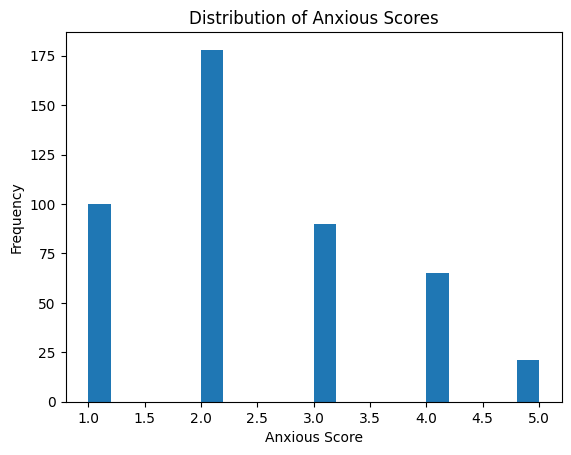

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_combined['anxious'].dropna(), bins=20)
plt.xlabel('Anxious Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anxious Scores')
plt.show()

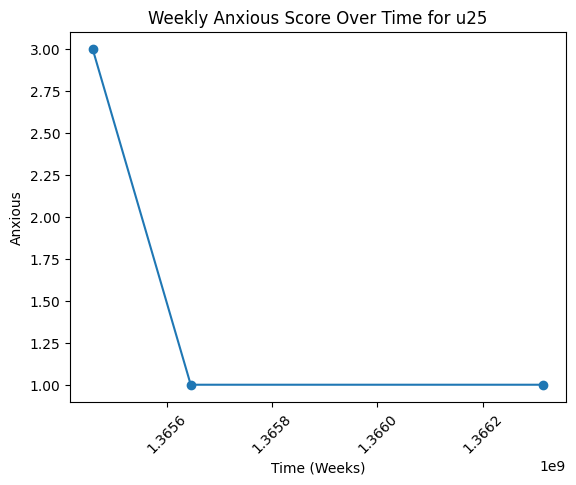

In [ ]:
user_of_interest = 'u25'
df_u25 = df_combined[df_combined['user_id']==user_of_interest].sort_values('resp_time')

plt.plot(df_u25['resp_time'], df_u25['anxious'], marker='o')
plt.xlabel('Time (Weeks)')
plt.ylabel('Anxious')
plt.title(f'Weekly Anxious Score Over Time for {user_of_interest}')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Example: Merge df_depression
df_depression = pd.read_csv("https://raw.githubusercontent.com/fanxu30/student_mental_health_ml/refs/heads/main/Data/Data_Clean/static/clean_PHQ-9.csv")
df_depression.rename(columns={'uid': 'user_id'}, inplace=True)
df_combined_final = df_final_filled.merge(df_depression, on=["user_id"], how='inner')

In [ ]:
df_combined_final.columns

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'positive_text', 'negative_text', 'weekday',
       'hour', 'exercise', 'walk', 'have', 'schedule', 'sleep_hours',
       'sleep_quality', 'sleepiness', 'number', 'user_id', 'datetime_utc',
       'gpa_all', 'type', 'Little interest or pleasure in doing things',
       'Feeling down, depressed, hopeless.',
       'Trouble falling or staying asleep, or sleeping too much.',
       'Feeling tired or having little energy', 'Poor appetite or overeating',
       'Feeling bad about yourself or that you are a failure or have let yourself or your family down',
       'Trouble concentrating on things, such as reading the newspaper or wat

In [ ]:
df_combined_final.shape

(7803, 51)

In [ ]:
df_depression.depression_severity.value_counts()

,count
depression_severity,
Minimal depression,34
Mild depression,29
Moderate depression,9
Moderately severe depression,3
Severe depression,3


In [ ]:
df_depression[df_depression['depression_severity'] == 'Severe depression']['total_score'].value_counts()

,count
total_score,
23,1
21,1
25,1


In [ ]:
feature_cols =  [
'anxious',
'calm',
'conventional',
'critical',
'dependable',
'disorganized',
'enthusiastic',
'experiences',
'reserved',
'sympathetic',
'due',
'experience',
'hours',
'happy',
'happyornot',
'sad',
'sadornot',
'level',
'positive_event_score',
'negative_event_score',
'emotion_range',
'has_positive_text',
'has_negative_text',
'positive_text',
'negative_text',
'weekday',
'hour',
'exercise',
'walk',
'have',
'schedule',
'sleep_hours',
'sleep_quality',
'sleepiness',
'number', 'gpa_all']

In [ ]:
df_combined_final['experience'].value_counts()

,count
experience,
3.0,3286
1.0,2617
2.0,915
4.0,788
5.0,197


In [ ]:
df_combined_final[feature_cols].isna().sum()

,0
anxious,0
calm,0
conventional,0
critical,0
dependable,0
disorganized,0
enthusiastic,0
experiences,0
reserved,0
sympathetic,0


In [ ]:
df_combined_final['level'].value_counts()

,count
level,
1.0,2834
4.0,1813
2.0,1474
3.0,1258
5.0,424


In [ ]:
df_combined_final['experience'].value_counts()

,count
experience,
3.0,3286
1.0,2617
2.0,915
4.0,788
5.0,197


In [ ]:
#change mapping of values for experience and stress level

# Create the mapping dictionary
mapping = {1: 3, 2: 1, 3: 2, 4: 4, 5: 5}

# Apply the mapping to the 'experience' column
df_combined_final['experience'] = df_combined_final['experience'].map(mapping)

mapping_level = {1: 3, 2: 2, 3: 1, 4: 4, 5: 5}

# Apply the mapping to the "level" column
df_combined_final['level'] = df_combined_final['level'].map(mapping_level)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

final_features = ['anxious',
 'calm',
 'conventional',
 'critical',
 'dependable',
 'disorganized',
 'enthusiastic',
 'experiences',
 'reserved',
 'sympathetic',
 'due',
 'experience',
 'hours',
 'happy',
 'happyornot',
 'sad',
 'sadornot',
 'level',
 'positive_event_score',
 'negative_event_score',
 'emotion_range',
 'has_positive_text',
 'has_negative_text',
 'hour',
 'exercise',
 'walk',
 'have',
 'schedule',
 'sleep_hours',
 'sleep_quality',
 'sleepiness',
 'number', 'gpa_all']
X = df_combined_final[final_features].copy()
y = df_combined_final['total_score'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Fit a simple linear regression
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_pred = reg.predict(X_test)

# Evaluate
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R^2:", r2)

MSE: 8.871520912682074
R^2: 0.7307536542486004


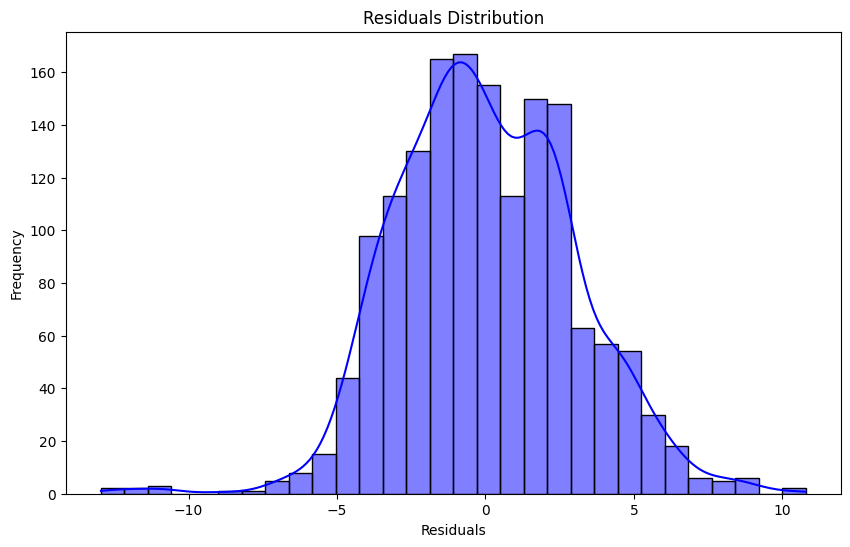

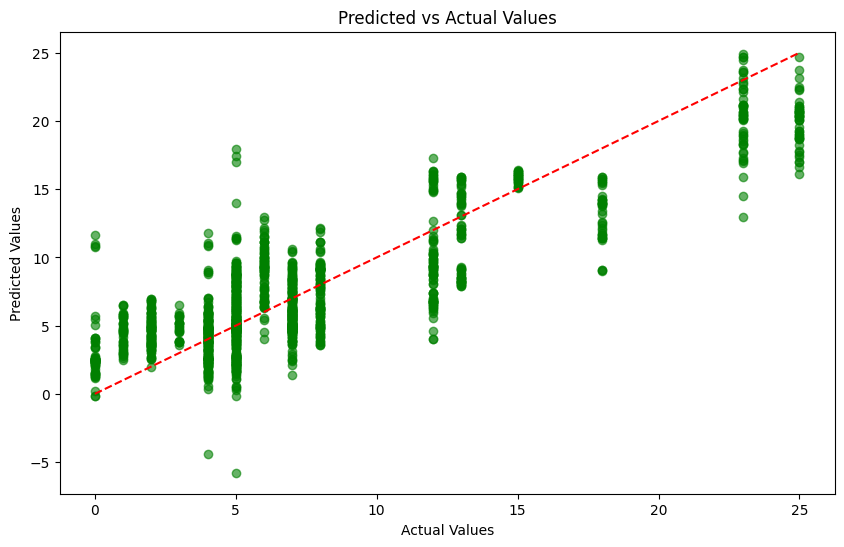

Shapiro-Wilk Test: Test Statistic = 0.9901201001352304, p-value = 8.802128728478685e-09
D'Agostino and Pearson's Test: Test Statistic = 18.307692611836035, p-value = 0.00010581203359570685


In [ ]:
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, normaltest

import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# Statistical analysis

# Shapiro-Wilk test for normality of residuals
shapiro_test_stat, shapiro_p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test: Test Statistic = {shapiro_test_stat}, p-value = {shapiro_p_value}")

# D'Agostino and Pearson's test for normality of residuals
dagostino_test_stat, dagostino_p_value = normaltest(residuals)
print(f"D'Agostino and Pearson's Test: Test Statistic = {dagostino_test_stat}, p-value = {dagostino_p_value}")

In [ ]:
X.head()

,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,sympathetic,...,hour,exercise,walk,have,schedule,sleep_hours,sleep_quality,sleepiness,number,gpa_all
0,1.0,5.0,2.0,2.0,2.0,3.0,5.0,2.0,2.0,4.0,...,4.0,3.0,2.0,1.0,1.0,8.0,2.0,1.0,3.0,3.505
1,1.0,5.0,2.0,2.0,2.0,3.0,5.0,2.0,2.0,4.0,...,4.0,3.0,2.0,1.0,1.0,8.0,2.0,1.0,3.0,3.505
2,1.0,5.0,2.0,2.0,2.0,3.0,5.0,2.0,2.0,4.0,...,4.0,3.0,2.0,1.0,1.0,8.0,2.0,1.0,3.0,3.505
3,1.0,5.0,2.0,2.0,2.0,3.0,5.0,2.0,2.0,4.0,...,4.0,3.0,2.0,1.0,1.0,8.0,2.0,1.0,3.0,3.505
4,1.0,5.0,2.0,2.0,2.0,3.0,5.0,2.0,2.0,4.0,...,4.0,3.0,2.0,1.0,1.0,8.0,2.0,1.0,3.0,3.505


In [ ]:
X.columns

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'hour', 'exercise', 'walk', 'have', 'schedule',
       'sleep_hours', 'sleep_quality', 'sleepiness', 'number', 'gpa_all'],
      dtype='object')

In [ ]:
pip install xgboost

In [ ]:
# 3) Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)


In [ ]:


# Check for duplicate rows in X_train
duplicate_rows = X_train[X_train.duplicated()]

if duplicate_rows.empty:
  print("No duplicate rows found in X_train.")
else:
  print("Duplicate rows found in X_train:")
duplicate_rows


Duplicate rows found in X_train:


,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,sympathetic,...,hour,exercise,walk,have,schedule,sleep_hours,sleep_quality,sleepiness,number,gpa_all
3977,2.0,4.0,4.0,1.0,4.0,2.0,3.0,3.0,4.0,3.0,...,4.0,1.0,3.0,2.0,1.0,5.0,4.0,2.0,1.0,3.719
267,2.0,3.0,3.0,2.0,4.0,2.0,3.0,3.0,4.0,3.0,...,16.0,5.0,3.0,1.0,1.0,6.0,2.0,1.0,3.0,3.029
1656,1.0,3.0,1.0,3.0,4.0,2.0,3.0,4.0,4.0,1.0,...,0.0,3.0,1.0,1.0,1.0,10.0,2.0,1.0,4.0,3.667
4584,1.0,5.0,3.0,1.0,4.0,1.0,4.0,4.0,2.0,4.0,...,2.0,1.0,2.0,2.0,2.0,9.0,2.0,1.0,6.0,3.826
216,2.0,4.0,3.0,3.0,3.0,1.0,5.0,4.0,2.0,5.0,...,7.0,3.0,2.0,1.0,2.0,9.0,1.0,2.0,3.0,3.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5226,2.0,4.0,3.0,2.0,3.0,3.0,2.0,2.0,4.0,2.0,...,2.0,1.0,2.0,2.0,2.0,7.0,3.0,3.0,4.0,3.790
5390,2.0,4.0,3.0,1.0,4.0,2.0,4.0,2.0,3.0,4.0,...,5.0,1.0,3.0,2.0,2.0,7.0,3.0,1.0,3.0,3.790
860,1.0,4.0,3.0,1.0,3.0,1.0,4.0,2.0,4.0,4.0,...,21.0,1.0,2.0,2.0,1.0,8.0,1.0,1.0,4.0,3.474
7603,2.0,3.0,3.0,3.0,4.0,2.0,2.0,2.0,3.0,5.0,...,20.0,1.0,3.0,2.0,2.0,16.0,1.0,1.0,4.0,3.519


In [ ]:
mask = ~X_train.duplicated(keep='first')  # True for unique rows
X_train = X_train[mask]
y_train = y_train[mask]

In [ ]:
(X_train.columns)

Index(['anxious', 'calm', 'conventional', 'critical', 'dependable',
       'disorganized', 'enthusiastic', 'experiences', 'reserved',
       'sympathetic', 'due', 'experience', 'hours', 'happy', 'happyornot',
       'sad', 'sadornot', 'level', 'positive_event_score',
       'negative_event_score', 'emotion_range', 'has_positive_text',
       'has_negative_text', 'hour', 'exercise', 'walk', 'have', 'schedule',
       'sleep_hours', 'sleep_quality', 'sleepiness', 'number', 'gpa_all'],
      dtype='object')

In [ ]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score



# 3) Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# 4) Set up XGB and param grid
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score (neg MSE):", grid_search.best_score_)

# 5) Evaluate on test set
best_model_xgb = grid_search.best_estimator_
y_pred = best_model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print("Test MSE:", mse)
print("Test R^2:", r2)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV score (neg MSE): -3.370292615890503
Test MSE: 3.453557014465332
Test R^2: 0.8951862454414368


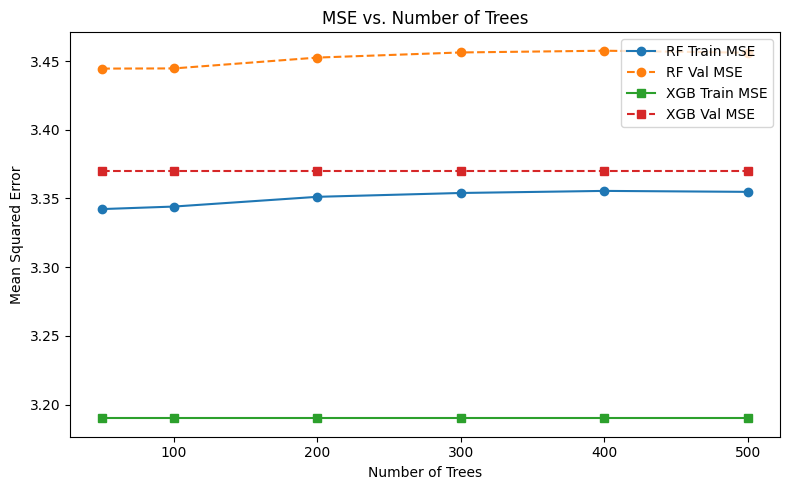

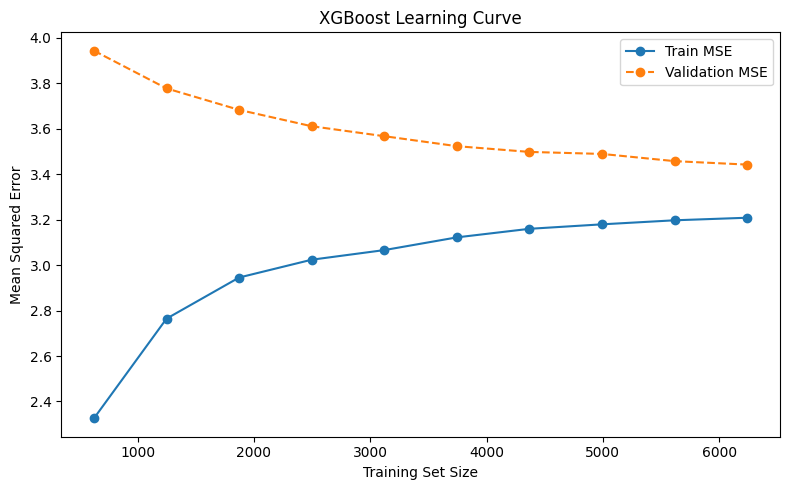

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# assume X_train, y_train, best_params from your GridSearchCV are already defined

# 1) MSE vs. Number of Trees (for RF and XGB)
n_estimators_list = [50, 100, 200, 300, 400, 500]

rf_train_mse, rf_val_mse = [], []
xgb_train_mse, xgb_val_mse = [], []
best_params={'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 400}
best_params_x= {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
for n in n_estimators_list:
    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_params.get('max_depth', None),
        random_state=42
    )
    cv_rf = cross_validate(
        rf, X_train, y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )
    rf_train_mse.append(-cv_rf['train_score'].mean())
    rf_val_mse.append(-cv_rf['test_score'].mean())

    # XGBoost (fix all other hyperparams at their best values)
    xgb = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=300,
        max_depth=best_params_x['max_depth'],
        learning_rate=best_params_x['learning_rate'],
        subsample=best_params_x['subsample'],
        colsample_bytree=best_params_x['colsample_bytree']
    )
    cv_xgb = cross_validate(
        xgb, X_train, y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        n_jobs=-1
    )
    xgb_train_mse.append(-cv_xgb['train_score'].mean())
    xgb_val_mse.append(-cv_xgb['test_score'].mean())


# Plot MSE vs n_estimators
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, rf_train_mse, 'o-', label='RF Train MSE')
plt.plot(n_estimators_list, rf_val_mse,  'o--', label='RF Val MSE')
plt.plot(n_estimators_list, xgb_train_mse, 's-', label='XGB Train MSE')
plt.plot(n_estimators_list, xgb_val_mse,  's--', label='XGB Val MSE')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()


# 2) Learning Curve: MSE vs. Training Set Size (for best XGB)
# combine train+test to use full X,y for a true learning curve
from sklearn.model_selection import ShuffleSplit

train_sizes, train_scores, val_scores = learning_curve(
    best_model_xgb,            # tuned XGBRegressor
    X, y,
    cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

train_mse = -train_scores.mean(axis=1)
val_mse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mse, 'o-', label='Train MSE')
plt.plot(train_sizes, val_mse,   'o--', label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

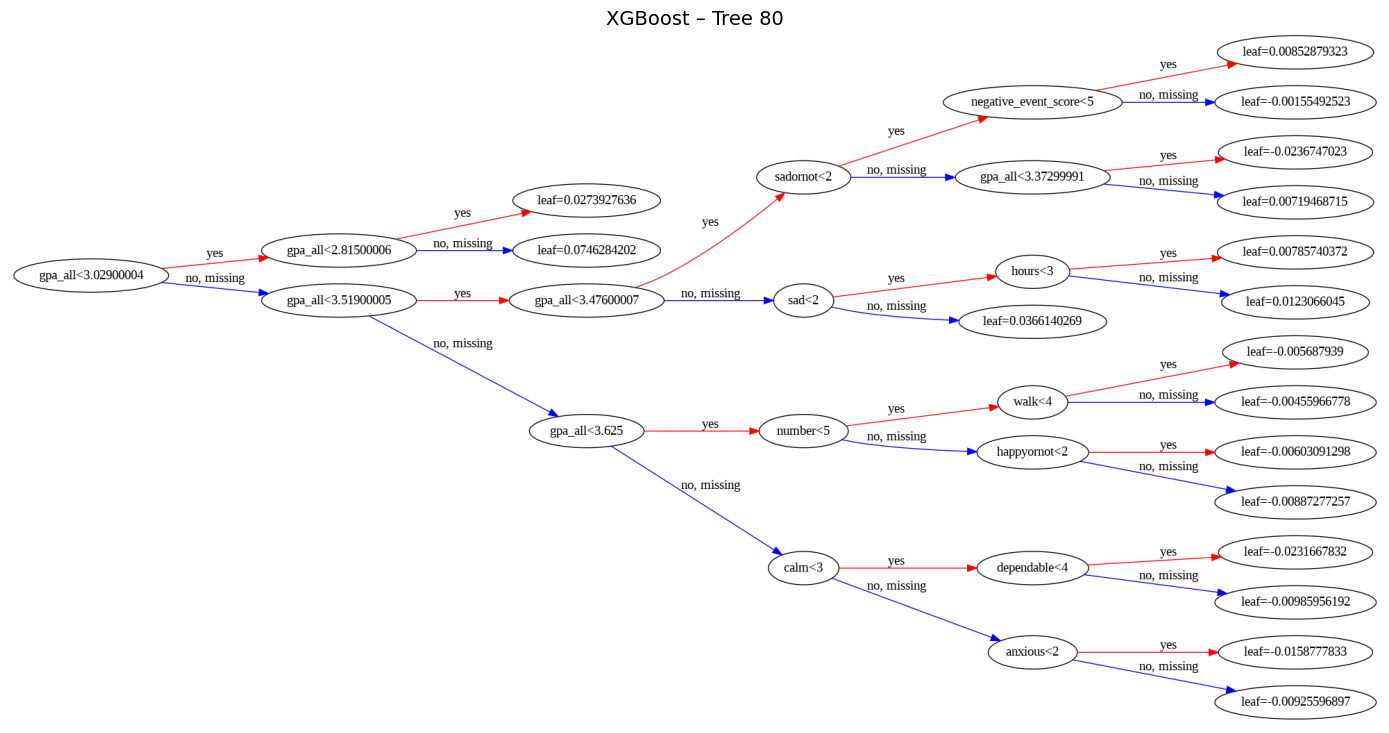

In [ ]:

import matplotlib.pyplot as plt
from xgboost import plot_tree

tree_idx = 80            # plot individual trees

fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(best_model_xgb, num_trees=tree_idx, rankdir='LR', ax=ax)  # LR = left→right
ax.set_title(f'XGBoost – Tree {tree_idx}', fontsize=14)
plt.tight_layout()
plt.show()

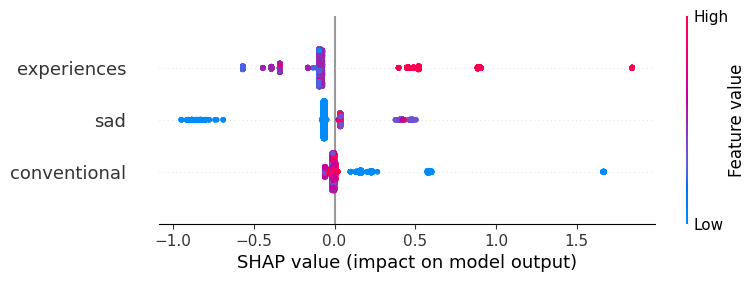

In [ ]:
import shap
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt



# -------- 2. Compute SHAP for the full feature set -----
explainer  = shap.TreeExplainer(best_model_xgb)
shap_vals  = explainer(X_train)     # SHAP values for every feature
                                     # shap_vals.values has shape (n_samples, 36)

# -------- 3. Keep only the features you want -----------
keep = ['sad', 'experiences', 'conventional']

# (a) Sub-select SHAP values
keep_idx        = [X_train.columns.get_loc(c) for c in keep]
shap_vals_small = shap.Explanation(
        values      = shap_vals.values[:, keep_idx],
        base_values = shap_vals.base_values,
        data        = X_train[keep].values,
        feature_names = keep
)

# -------- 4. Plot the reduced beeswarm  ----------------
shap.plots.beeswarm(shap_vals_small, show=True)   # only 4 bars/dot-clouds

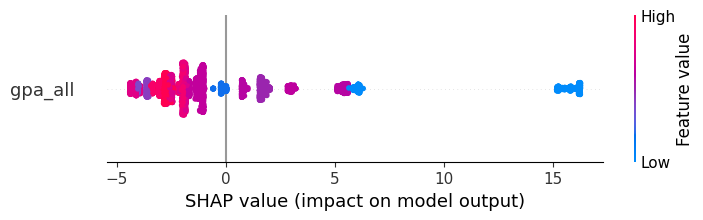

In [ ]:
import shap
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt



# -------- 2. Compute SHAP for the full feature set -----
explainer  = shap.TreeExplainer(best_model_xgb)
shap_vals  = explainer(X_train)     # SHAP values for every feature
                                     # shap_vals.values has shape (n_samples, 36)

# -------- 3. Keep only the features you want -----------
keep = ['gpa_all']

# (a) Sub-select SHAP values
keep_idx        = [X_train.columns.get_loc(c) for c in keep]
shap_vals_small = shap.Explanation(
        values      = shap_vals.values[:, keep_idx],
        base_values = shap_vals.base_values,
        data        = X_train[keep].values,
        feature_names = keep
)

# -------- 4. Plot the reduced beeswarm  ----------------
shap.plots.beeswarm(shap_vals_small, show=True)   # only 4 bars/dot-clouds

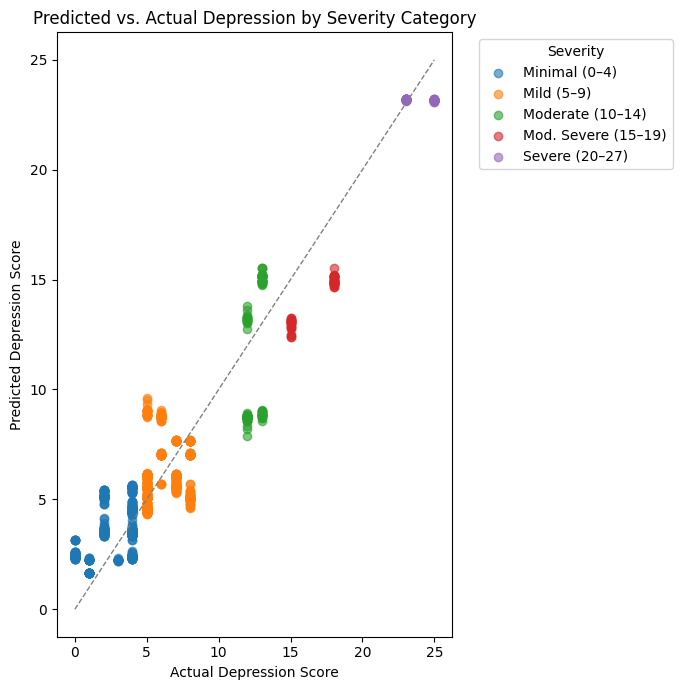

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Prepare DataFrame
df_plot = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
})

# Define PHQ-9 severity bins and labels
bins = [-0.1, 4, 9, 14, 19, 27]
labels = [
    'Minimal (0–4)',
    'Mild (5–9)',
    'Moderate (10–14)',
    'Mod. Severe (15–19)',
    'Severe (20–27)'
]
df_plot['severity'] = pd.cut(df_plot['actual'], bins=bins, labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(7,7))
for sev in labels:
    mask = df_plot['severity'] == sev
    ax.scatter(
        df_plot.loc[mask, 'actual'],
        df_plot.loc[mask, 'predicted'],
        label=sev,
        alpha=0.6
    )

# Identity line
min_val = df_plot[['actual', 'predicted']].min().min()
max_val = df_plot[['actual', 'predicted']].max().max()
ax.plot([min_val, max_val], [min_val, max_val], '--', color='gray', linewidth=1)

ax.set_xlabel('Actual Depression Score')
ax.set_ylabel('Predicted Depression Score')
ax.set_title('Predicted vs. Actual Depression by Severity Category')
ax.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Compute Adjusted R^2
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors/features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R^2:", adjusted_r2)

Adjusted R^2: 0.8929211151857507


In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assume you have a fitted XGBRegressor called `xgb_model`
# and a list of feature names in the same order you trained on:
feature_names = list(X.columns)  # e.g. ['anxious','calm',…,'hours']

# 1. Get raw importance scores
importances = best_model.feature_importances_

# 2. Build a DataFrame, sort descending
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# 3. Plot
plt.figure(figsize=(8,6))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('XGBoost Feature Importance')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

NameError: name 'best_model' is not defined

In [ ]:
pip install shap

In [ ]:
import shap

# 1. Create an explainer
explainer = shap.Explainer(best_model, X_train)

# 2. Compute SHAP values on your test set
shap_values = explainer(X_test)

# 3. Summary plot (global feature impact)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 4. Detailed summary (beeswarm)
shap.summary_plot(shap_values, X_test)

# 5. Dependence plot for one feature
shap.dependence_plot("anxious", shap_values.values, X_test, feature_names=feature_names)

In [ ]:
shap.dependence_plot("gpa_all", shap_values.values, X_test, feature_names=feature_names)

In [ ]:
shap.dependence_plot("experiences", shap_values.values, X_test, feature_names=feature_names)

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=['experiences'], ax=ax
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=['sad'], ax=ax
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=['gpa_all'], ax=ax
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=['conventional'], ax=ax
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=0)
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(perm_df['feature'], perm_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Permutation Importance (MSE increase)')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

#Get best hyperparameters from grid search
best_params = grid_search.best_params_

#Retrain on full data using best params
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)

final_model.fit(X, y)

# 8) Save the trained model as a pickle file
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final model retrained on full data and saved as 'xgb_final_model.pkl'")

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error


param_grid = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [5, 10, 15],
    'min_samples_leaf':  [1, 2, 4]
}


rf = RandomForestRegressor(
    criterion='squared_error',
    bootstrap=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)


grid_search.fit(X_train, y_train)


print("Best hyperparameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(X_test)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.4f}")

In [ ]:
r2  = r2_score(y_test, y_pred)
print("Test R^2:", r2)
#
# Compute Adjusted R^2
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors/features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R^2:", adjusted_r2)

In [ ]:
import pickle

#Get best hyperparameters from grid search
best_params = grid_search.best_params_

#Retrain on full data using best params
final_model = RandomForestRegressor(
    random_state=42,
    **best_params
)

final_model.fit(X, y)

# Save the trained model as a pickle file
with open("rf_model.pkl", "wb") as f:
    pickle.dump(final_model, f)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import xgboost as xgb
import shap
import numpy as np

# 1) Predicted vs actual
y_pred = best_model.predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual PHQ‑9'); plt.ylabel('Predicted PHQ‑9')
plt.title('Predicted vs. Actual (XGBoost)')
plt.tight_layout(); plt.show()

# 2) Residual histogram
resid = y_test - y_pred
plt.hist(resid, bins=20)
plt.xlabel('Residual'); plt.ylabel('Count')
plt.title('Residual distribution')
plt.tight_layout(); plt.show()

# 3) Permutation importance
perm = permutation_importance(best_model, X_test, y_test,
                              n_repeats=20, random_state=0)
imp_order = np.argsort(perm.importances_mean)[::-1]
plt.barh(np.array(feature_cols)[imp_order],
         perm.importances_mean[imp_order])
plt.gca().invert_yaxis()
plt.xlabel('MSE increase'); plt.title('Permutation Importance')
plt.tight_layout(); plt.show()

# 5) SHAP summary for local/global view
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [ ]:

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, axs = plt.subplots(2, 2, figsize=(6, 6))

PartialDependenceDisplay.from_estimator(
    best_model, X_test,
    features=['gpa_all'],
    kind='average', grid_resolution=20, ax=axs[0, 0]
)
axs[0, 0].set_title('Partial Dependence of gpa_all')

PartialDependenceDisplay.from_estimator(
    best_model, X_test,
    features=['sad'],
    kind='average', grid_resolution=20, ax=axs[0, 1]
)
axs[0, 1].set_title('Partial Dependence of sad')

PartialDependenceDisplay.from_estimator(
    best_model, X_test,
    features=['experiences'],
    kind='average', grid_resolution=20, ax=axs[1, 0]
)
axs[1, 0].set_title('Partial Dependence of experiences')

PartialDependenceDisplay.from_estimator(
    best_model, X_test,
    features=['conventional'],
    kind='average', grid_resolution=20, ax=axs[1, 1]
)
axs[1, 1].set_title('Partial Dependence of conventional')

plt.tight_layout()
plt.show()


In [ ]:
pip install statsmodels

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

##############################
# 1) Example: Ordinary Least Squares (OLS)
##############################

# Suppose your DataFrame is called df:
#  - df["depression_score"] is numeric from 0–25
#  - the other columns are your predictors

# Define predictor columns
feature_cols = ['anxious',
 'calm',
 'conventional',
 'critical',
 'dependable',
 'disorganized',
 'enthusiastic',
 'experiences',
 'reserved',
 'sympathetic',
 'due',
 'experience',
 'hours',
 'happy',
 'happyornot',
 'sad',
 'sadornot',
 'level',
 'positive_event_score',
 'negative_event_score',
 'emotion_range',
 'has_positive_text',
 'has_negative_text',
 'hour',
 'exercise',
 'walk',
 'have',
 'schedule',
 'sleep_hours',
 'sleep_quality',
 'sleepiness',
 'number', 'gpa_all']

# Build a formula string for OLS
formula_ols = "total_score ~ " + " + ".join(feature_cols)

# Fit the OLS model
model_ols = smf.ols(formula=formula_ols, data=df_combined_final).fit()

print("=== OLS Regression Results ===")
print(model_ols.summary())

# Interpretation:
# - The 'coef' column under each predictor shows how a one-unit change
#   in that predictor is associated with a change in depression_score,
#   controlling for the other predictors.
# - The p-values (P>|t|) show which predictors are statistically significant
# - R-squared shows how much variance is explained, and the F-statistic
#   tests if all predictors jointly have some explanatory power.

after removing happy from variables.
The key differences from the previous results are minimal:
	•	R-squared went from ~0.251 to ~0.250, essentially unchanged.
	•	Adjusted R-squared remains ~0.232.
	•	AIC went from ~3722 to ~3721 – a tiny (and likely negligible) improvement.

Overall, removing happy didn’t make the model “worse,” but it also didn’t materially improve fit or significantly alter the other coefficients. You may have removed some mild collinearity, but from a performance perspective, the difference is very slight.

1. Model Fit (High-Level)
	•	R-squared = 0.250
About 25% of the variance in depression score is explained.
	•	Adjusted R-squared = 0.232
Similar to the original model, meaning the set of predictors collectively explains ~23% once adjusted for the number of predictors.
	•	F-statistic = 13.62, p ≈ 5.63e-30
Highly significant overall. The set of 15 predictors still offers explanatory power for depression scores.

2. Key Significant Predictors
	1.	anxious (coef = +1.34, p = 0.003)
	•	A one‐point increase in “anxious” is associated with a ~+1.34 rise in total_score (holding others constant).
	2.	conventional (−2.19, p < 0.0001)
	•	More conventional → about 2.19 points lower depression score.
	3.	dependable (−1.56, p < 0.0001)
	•	More dependable → about 1.56 points lower depression score.
	4.	reserved (+1.22, p < 0.001)
	•	More reserved → about +1.22 in depression score.
	5.	sympathetic (+1.01, p = 0.031)
	•	More sympathetic → about +1.01 in depression score.
	6.	sad (+3.48, p < 0.0001)
	•	This remains the largest positive effect: each unit increase in “sad” → +3.48 points.
	7.	experience (+0.81, p = 0.009)
	•	More “experience” → ~+0.81 in depression score.

These effects are similar to before: sad remains the strongest positive predictor, while being conventional or dependable strongly lowers the predicted depression score.

3. Borderline or Non-Significant
	•	calm (p = 0.104)
	•	due (p = 0.076)
	•	critical, disorganized, enthusiastic, experiences (plural), level, hours – all > 0.05, suggesting they’re not statistically different from zero once controlling for the others.


In [ ]:

##############################
# 2) Example: Generalized Linear Model (GLM) with Gaussian + Identity
##############################

# The same model in GLM form:
formula_glm = "total_score ~ " + " + ".join(feature_cols)

# Fit a GLM with Gaussian family, identity link
model_glm = smf.glm(formula=formula_glm, data=df_combined_final,
                    family=sm.families.Gaussian(sm.families.links.identity())).fit()

print("\n=== GLM (Gaussian, Identity) Results ===")
print(model_glm.summary())

# Interpretation:
# - This is nearly identical to OLS in practice.
# - The 'coef' estimates, standard errors, etc. are interpreted similarly.
# - The difference is conceptual: GLM is part of a broader family.
#   For a roughly normal outcome (0–25 scale), this is fine.

##############################
# 3) Possible Alternative Models
##############################
# (No direct code below, just notes)

# - Ordinal Logistic/Probit Regression:
#   If you treat 'depression_score' (0–25) as ordinal categories
#   rather than truly continuous, you might prefer an ordinal model.
#   In Python, statsmodels has:
#     from statsmodels.miscmodels.ordinal_model import OrderedModel
#   But interpretability can be more complex (log-odds or threshold parameters).
#
# - Robust Regression:
#   If you have outliers or non-normal residuals, you could consider robust methods:
#     from statsmodels.robust.robust_linear_model import RLM
#
# - Non-parametric approaches:
#   If you suspect strong non-linearity or weird distribution, you might do
#   random forests, gradient boosting, or other machine-learning models,
#   though they won't provide the same straightforward coefficient-based inference.

Significant Variables: “sad,” “anxious,” “reserved,” “sympathetic,” “experience,” “conventional,” and “dependable” – the same set that emerged in OLS.

Model Performance: Captures roughly 25–28% of variance (moderate) – typical in psychological/behavioral contexts.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


influence = model_ols.get_influence()
cooks_d, pvals = influence.cooks_distance

# Let's plot Cook's distance:
fig, ax = plt.subplots()
ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.show()

# There's no absolute cutoff, but a rule-of-thumb is any Cook’s D above ~4/n
# (where n is number of observations) might be particularly influential.
n = len(X)
threshold = 4/n
potential_outliers = np.where(cooks_d > threshold)[0]
print("Potentially influential points (Cook's D > 4/n):", potential_outliers)

In [ ]:
hat_vals = influence.hat_matrix_diag
fig, ax = plt.subplots()
ax.stem(np.arange(len(hat_vals)), hat_vals, markerfmt=",")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Leverage (Hat value)")
plt.title("Hat Values for Each Observation")
plt.show()

# Typically, a rule-of-thumb cutoff is 2*(p+1)/n
# (where p is # of predictors, n is # of observations).
p = X.shape[1] - 1  # minus 1 because we added the constant
leverage_cutoff = 2*(p+1)/n
potential_high_leverage = np.where(hat_vals > leverage_cutoff)[0]
print("Points with high leverage (hat values):", potential_high_leverage)

In [ ]:
import statsmodels.api as sm
fig, ax = plt.subplots()
ax.scatter(model_ols.fittedvalues, model_ols.resid)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

# we see a curved pattern or funnel shape, it indicates
# potential non-linearity or heteroscedasticity.

In [ ]:
feature_cols

In [ ]:
import statsmodels.graphics.regressionplots as sgm

# E.g., let's see partial regression for "calm"
sgm.plot_regress_exog(model_ols, "anxious")
plt.show()

# This creates 4 subplots:
# 1) partial regression plot for calm
# 2) residuals vs. calm
# 3) ...
# and so forth.
#
# Look at the partial regression plot to see if there's any curvature.

In [ ]:
df_combined['anx_sq'] = df_combined['anxious']**2

# Then re-run the regression:
X = df_combined_final[feature_cols]
X = sm.add_constant(X)
model_poly = sm.OLS(y, X).fit()
print(model_poly.summary())

In [ ]:
import statsmodels.formula.api as smf
import patsy

# Using a spline basis for 'sad', for instance


formula_spline = "total_score ~ bs(sad, df=3) + anxious + conventional + dependable + sad + calm + critical + disorganized + enthusiastic + experiences + reserved + sympathetic + level + due + experience + hours + gpa_all"


formula_glm = "total_score ~ " + " + ".join(feature_cols)


model_spline = smf.ols(formula_spline, data=df_combined_final).fit()
print(model_spline.summary())

In [ ]:
#removing non- significant variables
#critical, disorganized, enthusiastic, experiences (plural), level, hours
import statsmodels.formula.api as smf
import patsy

# Using a spline basis for 'sad', for instance


formula_spline = "total_score ~ bs(sad, df=3) + anxious + conventional + dependable + sad + calm + reserved + sympathetic + due + experience + gpa_all"


formula_glm = "total_score ~ " + " + ".join(feature_cols)


model_spline = smf.ols(formula_spline, data=df_combined_final).fit()
print(model_spline.summary())

### refit modelw ithout outliers


In [ ]:
# refit both models without outliers


df_no_outliers = df_combined_final.drop(index=potential_outliers)

print("Original df shape:", df_combined_final.shape)
print("After dropping outliers:", df_no_outliers.shape)



In [ ]:


# Rebuild X and y from df_no_outliers
X_no_outliers = df_no_outliers[feature_cols]  # etc.
y_no_outliers = df_no_outliers['total_score']

X_no_outliers = sm.add_constant(X_no_outliers)
model_ols_no_outliers = sm.OLS(y_no_outliers, X_no_outliers).fit()

print("=== OLS Results without Outliers ===")
print(model_ols_no_outliers.summary())




In [ ]:
# The same model in GLM form:
formula_glm = "total_score ~ " + " + ".join(feature_cols)

# Fit a GLM with Gaussian family, identity link
model_glm_no_outliers = smf.glm(
    formula=formula_glm,
    data=df_no_outliers,
    family=sm.families.Gaussian(sm.families.links.identity())
).fit()

print("\n=== GLM (Gaussian, Identity) Results WITHOUT Outliers ===")
print(model_glm_no_outliers.summary())